<div style="background:linear-gradient(135deg,#0d47a1,#1565c0,#1976d2);padding:36px 28px;border-radius:14px;color:#fff;text-align:center">
<h1 style="margin:0;font-size:2.3em;letter-spacing:1px">⚗️ Notebook 1 — CSTR Isotérmico</h1>
<h2 style="margin:10px 0 4px;font-weight:300;font-size:1.2em">Capítulos 2 · 3 · 5 · 13 — Fogler (4ª Ed.)</h2>
<p style="margin:6px 0 0;opacity:.88;font-size:.97em">740484 Diseño de Reactores · Maestría y Doctorado en Ingeniería Química</p>
<p style="margin:4px 0 0;opacity:.78;font-size:.88em;font-style:italic">Universidad del Valle · Prof. José Antonio Lara Ramos, Ing. Qco., M.Sc., Ph.D.</p>
</div>

---

## 🎯 Objetivos del módulo

1. **Derivar** rigurosamente la ecuación de diseño del CSTR desde el teorema de transporte de Reynolds, sin atajos.
2. **Cuantificar** cómo el número de Damköhler controla la conversión y el tamaño del reactor.
3. **Interpretar** geométricamente el Diagrama de Levenspiel y demostrar la desigualdad $V_{CSTR} > V_{PFR}$ para $n>0$.
4. **Diseñar** cascadas de CSTRs en serie y calcular la eficiencia respecto al PFR equivalente.
5. **Construir** la tabla estequiométrica completa para reacciones gaseosas con cambio de volumen.
6. **Diagnosticar** comportamiento de reactores reales mediante la DTR del CSTR ideal.

## 📚 Mapa de referencias — Fogler 4ª Ed.

| Tema | Sección | Ecuación |
|------|---------|----------|
| Balance molar general | §1.4, Ec. 1-7 | $F_{j0}-F_j+\int r_j\,dV = dN_j/dt$ |
| Ecuación de diseño CSTR | §2.3, Ec. 2-13 | $V = F_{A0}X/(-r_A)$ |
| Número de Damköhler | §5.1, Ec. 5-4 | $Da = k\tau C_{A0}^{n-1}$ |
| Tabla estequiométrica gaseosa | §3.4, Tabla 3-4 | $C_A = C_{A0}(1-X)/(1+\varepsilon X)$ |
| CSTR en serie | §5.2.1, Ec. 5-15 | $X_N = 1-1/(1+k\tau_i)^N$ |
| DTR del CSTR | §13.2, Ec. 13-13 | $E(t) = e^{-t/\tau}/\tau$ |

## 🏭 Relevancia industrial

El CSTR es el reactor de flujo más simple desde el punto de vista del **análisis** (balance algebraico), pero al mismo tiempo es el más complejo de **operar** con seguridad cuando la reacción es exotérmica. Sus aplicaciones incluyen:

- Saponificación y hidrólisis catalítica (detergentes, glicoles).
- Polimerización continua en emulsión (látex, SBR, PVC en cascada de 5-10 CSTRs).
- Fermentación continua de etanol y producción de ácido cítrico.
- Tratamiento de aguas residuales industriales (reactores de lodos activados).
- Síntesis de colorantes y fármacos en batch equivalente a CSTR cuando $N_{batch}\to\infty$.


In [1]:
# ── Instalación e importaciones ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import (FancyBboxPatch, FancyArrowPatch,
                                 Arc, Ellipse)
from matplotlib.patheffects import withStroke
from scipy.integrate import cumulative_trapezoid, odeint
from scipy.optimize import brentq
from ipywidgets import interact, FloatSlider, IntSlider
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'figure.dpi': 110,
    'axes.titlesize': 11.5,
    'axes.labelsize': 11,
    'lines.linewidth': 2.3,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('✓ Entorno listo — numpy, scipy, matplotlib, ipywidgets')


✓ Entorno listo — numpy, scipy, matplotlib, ipywidgets


---
# 1. Derivación rigurosa de la ecuación de diseño del CSTR

## 1.1 Punto de partida: balance molar general

Todo el diseño de reactores parte de una única ecuación — el **balance molar generalizado** (Fogler §1.4, p. 8). Para la especie $A$ en un volumen de control arbitrario:

$$\underbrace{F_{A0}}_{\text{entrada}} - \underbrace{F_A}_{\text{salida}} + \underbrace{\int_0^V r_A\,dV}_{\text{generación}} = \underbrace{\frac{dN_A}{dt}}_{\text{acumulación}} \tag{1-7}$$

donde $r_A$ [mol/(m³·s)] puede variar con la posición dentro del reactor.

## 1.2 Imposición de las suposiciones del CSTR

El CSTR ideal requiere cuatro suposiciones. Cada una tiene una consecuencia matemática precisa:

| # | Suposición física | Consecuencia matemática | Justificación |
|---|-------------------|-------------------------|---------------|
| **S1** | **Mezcla perfecta** — el contenido está completamente homogéneo | $r_A(\vec{r}) = r_A = \text{cte}$ → la integral colapsa a $r_A\cdot V$ | Número de Péclet axial $Pe\to 0$ |
| **S2** | **Estado estacionario** | $dN_A/dt = 0$ | Operación continua estabilizada |
| **S3** | **Volumen constante** | $V\neq V(t)$ | Reactor de pared rígida |
| **S4** | **T y P uniformes** | $r_A = r_A(C_A, T)$ evaluado a condiciones de **salida** | Consecuencia de S1 |

Aplicando **S1** → integral en (1-7) colapsa:
$$F_{A0} - F_A + r_A V = \frac{dN_A}{dt}$$

Aplicando **S2** → lado derecho = 0:
$$F_{A0} - F_A = -r_A\,V \tag{2-12}$$

## 1.3 Introducción de la conversión fraccional

$$X_A \equiv \frac{F_{A0} - F_A}{F_{A0}} \implies F_A = F_{A0}(1-X_A)$$

Sustituyendo (y usando la convención $-r_A > 0$ para consumo de A):

$$\boxed{V_\text{CSTR} = \frac{F_{A0}\,X_A}{-r_A\big|_\text{salida}}} \tag{2-13}$$

### Forma adimensional — tiempo espacial

Usando $F_{A0} = v_0 C_{A0}$:

$$\tau \equiv \frac{V}{v_0} = \frac{C_{A0}\,X_A}{-r_A}$$

## 1.4 Número de Damköhler: el parámetro de diseño universal

Para cinética de **orden $n$** ($-r_A = kC_A^n$) con $C_A = C_{A0}(1-X)$ (fase líquida):

$$Da \equiv k\,\tau\,C_{A0}^{n-1}$$

Para **1er orden** ($n=1$): $Da = k\tau$, y la ecuación de diseño se resuelve explícitamente:

$$X_A = \frac{Da}{1+Da}$$

Esta expresión es central: **el ingeniero elige el tamaño del reactor (a través de $\tau$) para alcanzar el $Da$ necesario que garantice la conversión deseada**.

| $Da$ | $X_A$ (1er orden) | Interpretación del sistema |
|------|------------------|-----------------------------|
| 0.01 | 1.0% | Reactor infinitamente pequeño; reacción apenas comienza |
| 0.1 | 9.1% | Controlado por cinética — el reactor es el cuello de botella |
| 1.0 | 50.0% | Equilibrio entre reacción y flujo |
| 4.0 | 80.0% | **Diseño típico** (Example 5-1 de Fogler) |
| 10.0 | 90.9% | Controlado por flujo — el reactor es muy grande |
| 100 | 99.0% | Extremadamente sobredimensionado |

> **Regla de diseño**: apuntar a $Da \in [3, 10]$ equilibra costo de inversión y rendimiento. Valores mayores son antieconómicos; menores son ineficientes.

## 1.5 ¿Por qué el CSTR opera siempre a la velocidad más baja?

Esta es **la diferencia fundamental** con el PFR:

- En el PFR: las moléculas se mueven a través de gradientes de concentración. Al entrar, $C_A = C_{A0}$ (máximo) → velocidad máxima. Al salir, $C_A = C_{A0}(1-X)$ (mínimo) → velocidad mínima.
- En el CSTR: por **mezcla perfecta**, no hay gradientes. Todo el volumen está a $C_A = C_{A0}(1-X)$ — la concentración de **salida**, la más baja.

El CSTR es como un corredor de maratón que siempre corre a la velocidad de llegada (la más baja), en lugar de comenzar rápido y desacelerarse progresivamente como hace el PFR.

**Consecuencia cuantitativa**: para $X_A=0.8$, $n=1$:
$$\frac{V_\text{CSTR}}{V_\text{PFR}} = \frac{X/(1-X)}{-\ln(1-X)} = \frac{4}{1.609} = 2.49$$

El CSTR necesita 2.49 veces más volumen que el PFR para la misma conversión.


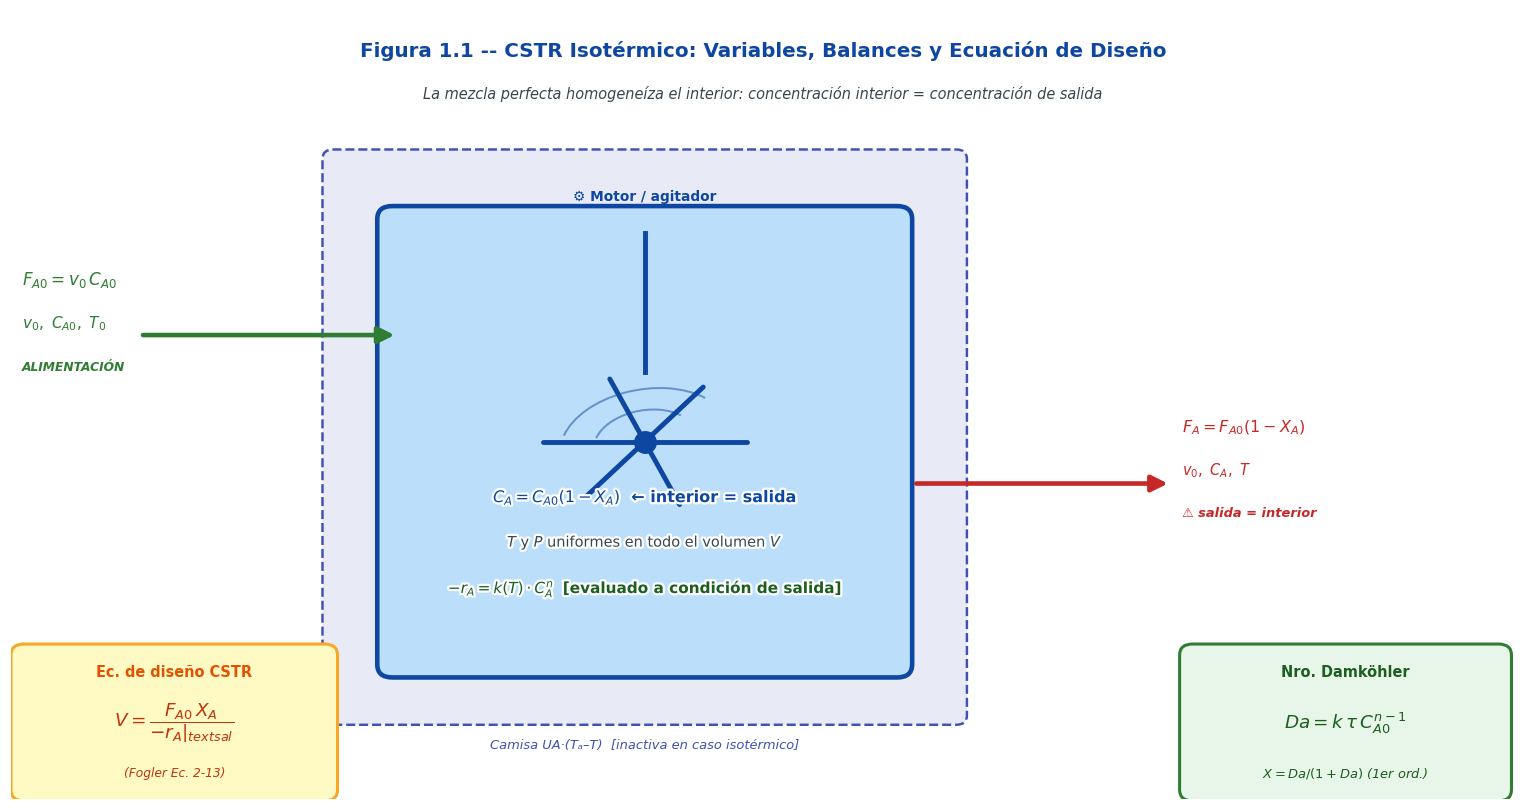

Figura 1.1 guardada.


In [10]:
import os
# -- Figura 1.1: Diagrama esquemático del CSTR con anotaciones --
fig, ax = plt.subplots(figsize=(14, 7.5))
ax.set_xlim(0, 14); ax.set_ylim(0, 8.5)
ax.axis('off'); ax.set_facecolor('#f5f7fb')
pe_w = [withStroke(linewidth=3, foreground='white')]

# -- Camisa de calefacción/enfriamiento (referencia) --
cam = FancyBboxPatch((3.0, 0.9), 5.8, 6.0,
                     boxstyle='round,pad=0.10',
                     facecolor='#E8EAF6', edgecolor='#3F51B5',
                     lw=1.6, ls='--')
ax.add_patch(cam)
ax.text(5.9, 0.55, 'Camisa UA·(Tₐ–T)  [inactiva en caso isotérmico]',
        ha='center', fontsize=8.5, color='#3F51B5', style='italic')

# -- Tanque principal --
tank = FancyBboxPatch((3.55, 1.45), 4.7, 4.8,
                      boxstyle='round,pad=0.14',
                      facecolor='#BBDEFB', edgecolor='#0D47A1', lw=3.0)
ax.add_patch(tank)

# -- Agitador --
cx, cy = 5.9, 3.85
ax.plot([cx, cx], [cy+0.75, 6.1], color='#0D47A1', lw=3.2)
for ang in [0, 55, 110, 180, 235, 290]:
    ax.plot([cx, cx+0.95*np.cos(np.radians(ang))],
            [cy, cy+0.72*np.sin(np.radians(ang))],
            color='#0D47A1', lw=3.2, solid_capstyle='round')
ax.plot(cx, cy, 'o', color='#0D47A1', ms=14, zorder=6)
for r in [0.48, 0.80]:
    arc = Arc((cx, cy), 2*r, 2*r*0.7, angle=15,
              theta1=25, theta2=160, color='#0D47A1', lw=1.3, alpha=0.5)
    ax.add_patch(arc)
ax.text(cx, 6.45, '⚙ Motor / agitador', ha='center', fontsize=9,
        color='#0D47A1', fontweight='bold')

# -- Texto interior --
ax.text(cx, 3.20, r'$C_A = C_{A0}(1-X_A)$  ← interior = salida',
        ha='center', fontsize=10.5, color='#0D47A1', fontweight='bold',
        path_effects=pe_w)
ax.text(cx, 2.72, r'$T$ y $P$ uniformes en todo el volumen $V$',
        ha='center', fontsize=9.5, color='#37474F', path_effects=pe_w)
ax.text(cx, 2.22, r'$-r_A = k(T)\cdot C_A^n\;$ [evaluado a condición de salida]',
        ha='center', fontsize=10, color='#1B5E20', fontweight='bold',
        path_effects=pe_w)

# -- Flujo entrada --
ax.annotate('', xy=(3.6, 5.0), xytext=(1.2, 5.0),
            arrowprops=dict(arrowstyle='-|>', color='#2E7D32',
                            lw=3.0, mutation_scale=22))
ax.text(0.1, 5.55, r'$F_{A0} = v_0\,C_{A0}$', fontsize=11,
        color='#2E7D32', fontweight='bold')
ax.text(0.1, 5.08, r'$v_0,\ C_{A0},\ T_0$', fontsize=10, color='#2E7D32')
ax.text(0.1, 4.62, 'ALIMENTACIÓN', fontsize=8, color='#2E7D32',
        style='italic', fontweight='bold')

# -- Flujo salida --
ax.annotate('', xy=(10.8, 3.40), xytext=(8.4, 3.40),
            arrowprops=dict(arrowstyle='-|>', color='#C62828',
                            lw=3.0, mutation_scale=22))
ax.text(10.9, 3.96, r'$F_A = F_{A0}(1-X_A)$', fontsize=10.5,
        color='#C62828', fontweight='bold')
ax.text(10.9, 3.50, r'$v_0,\ C_A,\ T$', fontsize=9.5, color='#C62828')
ax.text(10.9, 3.05, '⚠ salida = interior', fontsize=8.5,
        color='#C62828', fontweight='bold', style='italic')

# -- Box ecuación de diseño --
bx1 = FancyBboxPatch((0.12, 0.10), 2.80, 1.45,
                     boxstyle='round,pad=0.12',
                     facecolor='#FFF9C4', edgecolor='#F9A825', lw=2.0)
ax.add_patch(bx1)
ax.text(1.52, 1.32, 'Ec. de diseño CSTR', ha='center',
        fontsize=9.5, fontweight='bold', color='#E65100')
ax.text(1.52, 0.78, r'$V = \dfrac{F_{A0}\,X_A}{-r_A|_{text{sal}}}$',
        ha='center', fontsize=12, color='#BF360C', fontweight='bold')
ax.text(1.52, 0.24, '(Fogler Ec. 2-13)', ha='center',
        fontsize=8, color='#BF360C', style='italic')

# -- Box Damköhler --
bx2 = FancyBboxPatch((11.0, 0.10), 2.85, 1.45,
                     boxstyle='round,pad=0.12',
                     facecolor='#E8F5E9', edgecolor='#2E7D32', lw=2.0)
ax.add_patch(bx2)
ax.text(12.42, 1.32, 'Nro. Damköhler', ha='center',
        fontsize=9.5, fontweight='bold', color='#1B5E20')
ax.text(12.42, 0.76, r'$Da = k\,\tau\,C_{A0}^{n-1}$',
        ha='center', fontsize=12, color='#1B5E20', fontweight='bold')
ax.text(12.42, 0.24, r'$X = Da/(1+Da)$ (1er ord.)',
        ha='center', fontsize=8.5, color='#1B5E20', style='italic')

# -- Título --
ax.text(7.0, 8.0, 'Figura 1.1 -- CSTR Isotérmico: Variables, Balances y Ecuación de Diseño',
        ha='center', fontsize=13, fontweight='bold', color='#0D47A1')
ax.text(7.0, 7.55, 'La mezcla perfecta homogeneíza el interior: concentración interior = concentración de salida',
        ha='center', fontsize=9.5, color='#37474F', style='italic')

plt.tight_layout()

output_dir = '/home/claude/reactores'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'fig1_cstr_diagrama.png'),
            dpi=130, bbox_inches='tight', facecolor='#f5f7fb')
plt.show()
print('Figura 1.1 guardada.')

---
# 2. Fogler Example 5-1: Producción de Propilenglicol

## 2.1 Contexto de la industria química

El **1,2-propilenglicol** (PG) es un producto de ~2 Mt/año global con múltiples usos:

- **Anticongelante no tóxico** (GRAS — Generally Recognized As Safe) en sistemas hidráulicos de aeronaves y alimentos.
- **Excipiente farmacéutico** — vehículo en inyectables, óvulos, cápsulas blandas.
- **Monómero de poliéster** insaturado para resinas y pinturas.
- **Humectante** en tabaco, cosméticos, higiene oral.

La **ruta industrial dominante** (Dow, BASF, LyondellBasell) es la **hidratación no catalítica** del óxido de propileno a 120-180°C, pero la **ruta catalítica ácida** (H₂SO₄) a temperatura cercana a ambiente opera típicamente en **CSTRs** o **reactores de cascada**.

Reacción:
$$\underbrace{\text{C}_3\text{H}_6\text{O}}_{\text{óxido de propileno (A)}} + \underbrace{\text{H}_2\text{O}}_{\text{exceso (B)}} \;\xrightarrow{\text{H}_2\text{SO}_4}\; \underbrace{\text{C}_3\text{H}_8\text{O}_2}_{\text{propilenglicol (C)}}$$

Cinética (Fogler p. 164): **pseudo-1er orden** en A por exceso de agua: $-r_A = k\,C_A$ con $k = 0.257\,\text{min}^{-1}$ a 300 K.

## 2.2 Datos del problema (Fogler p. 175)

| Variable | Símbolo | Valor | Unidades |
|----------|---------|-------|----------|
| Constante cinética | $k$ | 0.257 | min⁻¹ |
| Concentración inicial A | $C_{A0}$ | 2.05 | mol/dm³ |
| Caudal volumétrico | $v_0$ | 46.8 | dm³/min |
| Flujo molar A | $F_{A0} = C_{A0}v_0$ | 95.94 | mol/min |
| Conversión requerida | $X_A$ | 0.80 | — |

## 2.3 Solución analítica — 4 pasos fundamentales

**Paso 1** — Velocidad de reacción evaluada a las condiciones de **salida** (S4: mezcla perfecta):
$$C_A\big|_\text{sal} = C_{A0}(1-X_A) = 2.05\times 0.20 = 0.410\;\text{mol/dm}^3$$
$$(-r_A)\big|_\text{sal} = k\,C_A\big|_\text{sal} = 0.257\times 0.410 = 0.1054\;\text{mol/(dm}^3\cdot\text{min)}$$

**Paso 2** — Aplicar la ecuación de diseño:
$$V = \frac{F_{A0}\,X_A}{(-r_A)} = \frac{95.94\times 0.80}{0.1054} = \mathbf{728\;\text{dm}^3}$$

**Paso 3** — Tiempo espacial:
$$\tau = \frac{V}{v_0} = \frac{728}{46.8} = 15.56\;\text{min}$$

**Paso 4** — Verificación mediante Damköhler:
$$Da = k\tau = 0.257\times 15.56 = 4.00 \implies X = \frac{4.00}{5.00} = 0.800\;\checkmark$$

## 2.4 Análisis de sensibilidad — reflexiones de ingeniería

**¿Qué pasa si queremos 90% de conversión?**

$$\tau_{90\%} = \frac{X}{k(1-X)} = \frac{0.9}{0.257\times 0.1} = 35.02\;\text{min}$$
$$V_{90\%} = 35.02\times 46.8 = 1640\;\text{dm}^3 = \mathbf{2.25\times V_{80\%}}$$

Pasar de 80% a 90% de conversión cuesta **2.25 veces más volumen** — la penalización asintótica del CSTR se hace evidente. La raíz es que el reactor opera a la velocidad de reacción más baja, y al ir hacia $X\to 1$ esa velocidad se acerca a cero.

**¿Qué pasa si la cinética cambia un 10%?** (cambio de catalizador, temperatura, etc.)

$$\frac{\partial V}{\partial k}\bigg|_X = -\frac{F_{A0}X}{k^2 C_{A0}(1-X)} = -\frac{V}{k}$$

Un error del 10% en $k$ se propaga directamente como un 10% de error en $V$ (relación **lineal**). Esto difiere del PFR donde el error en $k$ afecta el diseño logarítmicamente.


════════════════════════════════════════════════════════════
  FOGLER EXAMPLE 5-1 — CSTR Isotérmico — Propilenglicol
════════════════════════════════════════════════════════════
  k            = 0.257 min⁻¹
  C_A,sal      = 2.05×0.20 = 0.4100 mol/dm³
  −r_A|sal     = 0.257×0.4100 = 0.1054 mol/(dm³·min)
  F_A0         = 46.8×2.05 = 95.94 mol/min
  V = F_A0·X/(−r_A) = 95.94×0.8/0.1054 = 728.4 dm³
  τ = V/v₀    = 728.4/46.8 = 15.56 min
  Da = k·τ    = 0.257×15.56 = 4.000
  X = Da/(1+Da) = 4.000/5.000 = 0.8000  ✓
════════════════════════════════════════════════════════════


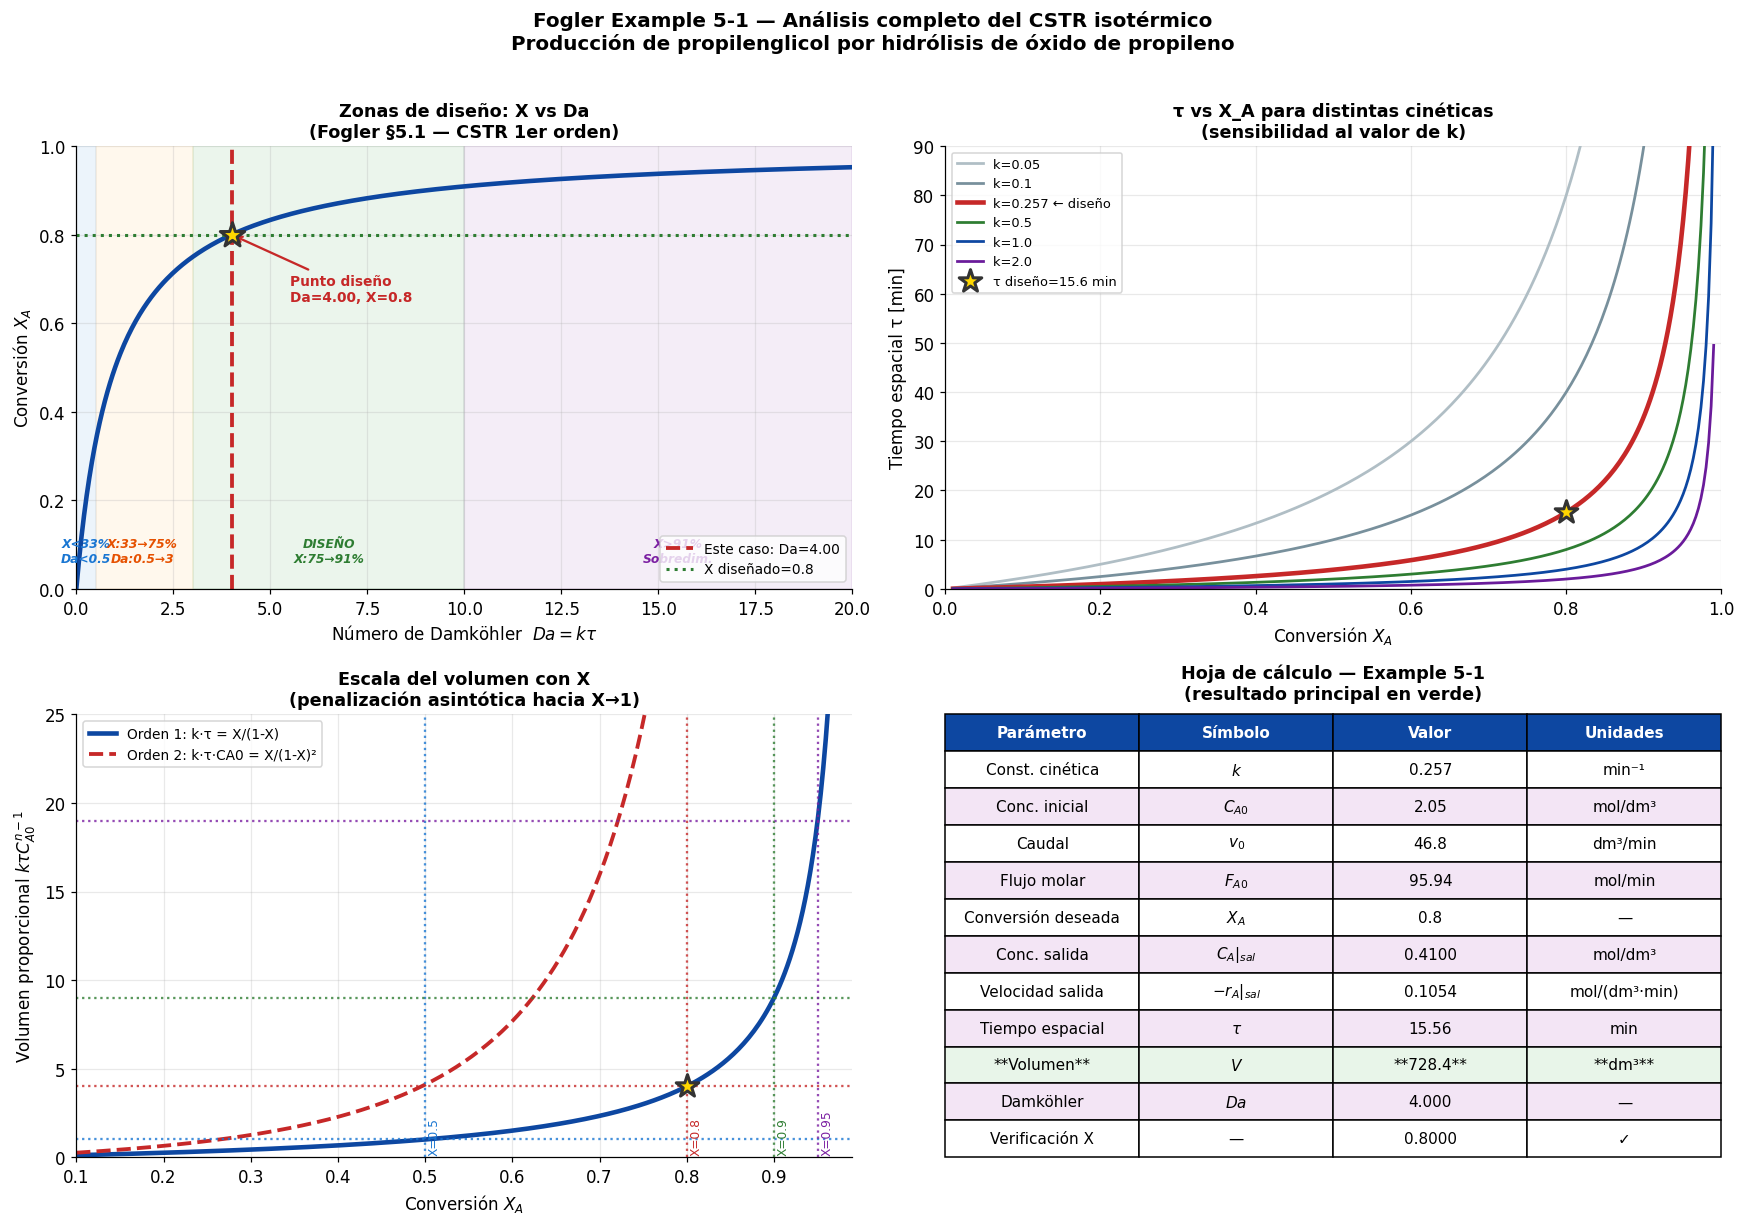

Figura 2 guardada.


In [11]:
# ── Example 5-1: Cálculo + análisis gráfico de 4 paneles ────────
k     = 0.257    # min^-1
CA0   = 2.05     # mol/dm^3
v0    = 46.8     # dm^3/min
X_des = 0.80
FA0   = v0 * CA0

# Resultados numéricos
CA_sal  = CA0 * (1 - X_des)
rA_sal  = k * CA_sal
V       = FA0 * X_des / rA_sal
tau     = V / v0
Da      = k * tau

print('═'*60)
print('  FOGLER EXAMPLE 5-1 — CSTR Isotérmico — Propilenglicol')
print('═'*60)
print(f'  k            = {k} min⁻¹')
print(f'  C_A,sal      = {CA0}×{1-X_des:.2f} = {CA_sal:.4f} mol/dm³')
print(f'  −r_A|sal     = {k}×{CA_sal:.4f} = {rA_sal:.4f} mol/(dm³·min)')
print(f'  F_A0         = {v0}×{CA0} = {FA0:.2f} mol/min')
print(f'  V = F_A0·X/(−r_A) = {FA0:.2f}×{X_des}/{rA_sal:.4f} = {V:.1f} dm³')
print(f'  τ = V/v₀    = {V:.1f}/{v0} = {tau:.2f} min')
print(f'  Da = k·τ    = {k}×{tau:.2f} = {Da:.3f}')
print(f'  X = Da/(1+Da) = {Da:.3f}/{1+Da:.3f} = {Da/(1+Da):.4f}  ✓')
print('═'*60)

# ── Gráfico de 4 paneles ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Fogler Example 5-1 — Análisis completo del CSTR isotérmico\n'
             'Producción de propilenglicol por hidrólisis de óxido de propileno',
             fontsize=13, fontweight='bold', y=1.01)

# ── Panel [0,0]: X vs Da con zonas ────────────────────────────
ax = axes[0,0]
Da_arr = np.linspace(0, 20, 600)
X_arr  = Da_arr / (1 + Da_arr)
ax.plot(Da_arr, X_arr, '#0D47A1', lw=3)
# Zonas de diseño con colores suaves
ax.axvspan(0,   0.5, alpha=0.08, color='#1976D2')
ax.axvspan(0.5, 3.0, alpha=0.08, color='#FFA726')
ax.axvspan(3.0, 10., alpha=0.10, color='#43A047')
ax.axvspan(10., 20., alpha=0.08, color='#7B1FA2')
# Anotaciones de zonas
for x_c, txt, col in [(0.25,  'X<33%\nDa<0.5',  '#1976D2'),
                       (1.7,   'X:33→75%\nDa:0.5→3','#E65100'),
                       (6.5,   'DISEÑO\nX:75→91%', '#2E7D32'),
                       (15.5,  'X>91%\nSobredim.', '#7B1FA2')]:
    ax.text(x_c, 0.06, txt, fontsize=8, ha='center', color=col,
            fontweight='bold', style='italic')
ax.axvline(Da, color='#C62828', ls='--', lw=2.5, label=f'Este caso: Da={Da:.2f}')
ax.axhline(X_des, color='#2E7D32', ls=':', lw=2, label=f'X diseñado={X_des}')
ax.scatter([Da], [X_des], s=280, color='gold', zorder=9,
           edgecolors='#333', lw=2, marker='*')
ax.annotate(f'Punto diseño\nDa={Da:.2f}, X={X_des}',
            xy=(Da, X_des), xytext=(Da+1.5, X_des-0.15),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5),
            fontsize=9, color='#C62828', fontweight='bold')
ax.set_xlabel('Número de Damköhler  $Da = k\\tau$')
ax.set_ylabel('Conversión $X_A$')
ax.set_title('Zonas de diseño: X vs Da\n(Fogler §5.1 — CSTR 1er orden)')
ax.set_ylim(0, 1); ax.set_xlim(0, 20)
ax.legend(fontsize=9, loc='lower right')

# ── Panel [0,1]: τ vs X para diferentes k ────────────────────
ax2 = axes[0,1]
X_p = np.linspace(0.01, 0.99, 300)
for k_i, col in zip([0.05, 0.10, 0.257, 0.50, 1.0, 2.0],
                    ['#B0BEC5','#78909C','#C62828','#2E7D32','#0D47A1','#6A1B9A']):
    tau_i = X_p / (k_i * (1 - X_p))
    lw = 3 if k_i == 0.257 else 1.8
    ax2.plot(X_p, tau_i, color=col, lw=lw,
             label=f'k={k_i} {"← diseño" if k_i==0.257 else ""}')
ax2.scatter([X_des], [tau], s=240, color='gold', zorder=9,
            edgecolors='#333', lw=2, marker='*',
            label=f'τ diseño={tau:.1f} min')
ax2.set_xlabel('Conversión $X_A$')
ax2.set_ylabel('Tiempo espacial τ [min]')
ax2.set_title('τ vs X_A para distintas cinéticas\n(sensibilidad al valor de k)')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 90)
ax2.legend(fontsize=8.5, loc='upper left')

# ── Panel [1,0]: Costo de volumen por punto de conversión ─────
ax3 = axes[1,0]
X_p2 = np.linspace(0.10, 0.98, 300)
V_rel_1 = X_p2 / (1 - X_p2) / (0.5/0.5)    # normalizado a X=0.5
V_rel_2 = X_p2**2 / ((1-X_p2)**2 * 0.5**2) # orden 2 aprox

ax3.plot(X_p2, X_p2/(1-X_p2), '#0D47A1', lw=3, label='Orden 1: k·τ = X/(1-X)')
ax3.plot(X_p2, X_p2/((1-X_p2)**2)*CA0,
         '#C62828', lw=2.5, ls='--', label='Orden 2: k·τ·CA0 = X/(1-X)²')
for xv, col in zip([0.5, 0.8, 0.9, 0.95],
                   ['#1976D2','#C62828','#2E7D32','#7B1FA2']):
    val = xv/(1-xv)
    ax3.axvline(xv, color=col, ls=':', lw=1.5, alpha=0.8)
    ax3.axhline(val, color=col, ls=':', lw=1.5, alpha=0.8)
    ax3.text(xv+0.003, 0.3, f'X={xv}', fontsize=8, color=col, rotation=90)
ax3.scatter([X_des], [X_des/(1-X_des)], s=240, color='gold', zorder=9,
            edgecolors='#333', lw=2, marker='*')
ax3.set_xlabel('Conversión $X_A$')
ax3.set_ylabel(r'Volumen proporcional $k\tau C_{A0}^{n-1}$')
ax3.set_title('Escala del volumen con X\n(penalización asintótica hacia X→1)')
ax3.set_xlim(0.1, 0.99); ax3.set_ylim(0, 25)
ax3.legend(fontsize=9)

# ── Panel [1,1]: Tabla de resultados ─────────────────────────
ax4 = axes[1,1]; ax4.axis('off')
datos = [
    ['Parámetro', 'Símbolo', 'Valor', 'Unidades'],
    ['Const. cinética', '$k$', f'{k}', 'min⁻¹'],
    ['Conc. inicial', '$C_{A0}$', f'{CA0}', 'mol/dm³'],
    ['Caudal', '$v_0$', f'{v0}', 'dm³/min'],
    ['Flujo molar', '$F_{A0}$', f'{FA0:.2f}', 'mol/min'],
    ['Conversión deseada', '$X_A$', f'{X_des}', '—'],
    ['Conc. salida', '$C_A|_{sal}$', f'{CA_sal:.4f}', 'mol/dm³'],
    ['Velocidad salida', '$-r_A|_{sal}$', f'{rA_sal:.4f}', 'mol/(dm³·min)'],
    ['Tiempo espacial', '$\\tau$', f'{tau:.2f}', 'min'],
    ['**Volumen**', '$V$', f'**{V:.1f}**', '**dm³**'],
    ['Damköhler', '$Da$', f'{Da:.3f}', '—'],
    ['Verificación X', '—', f'{Da/(1+Da):.4f}', '✓'],
]
tbl = ax4.table(cellText=datos[1:], colLabels=datos[0],
                cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for j in range(4):
    tbl[0,j].set_facecolor('#0D47A1')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(datos)):
    bg = '#E8F5E9' if i == 9 else ('#F3E5F5' if i%2==0 else 'white')
    for j in range(4): tbl[i,j].set_facecolor(bg)
ax4.set_title('Hoja de cálculo — Example 5-1\n(resultado principal en verde)',
              fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('/home/claude/reactores/fig2_ex51.png',
            dpi=120, bbox_inches='tight')
plt.show()
print('Figura 2 guardada.')


---
# 3. Diagrama de Levenspiel — interpretación geométrica

## 3.1 Origen y significado

Octave Levenspiel (Oregon State University, 1926-2017) propuso en 1962 visualizar las ecuaciones de diseño como **áreas geométricas** en el plano $(X_A, F_{A0}/(-r_A))$. Esto permite:

- **Comparar** reactores sin cálculo numérico.
- **Identificar** configuraciones óptimas para cinéticas complejas.
- **Diseñar gráficamente** series de CSTRs, PFRs o combinaciones.

La función a graficar es:
$$f(X_A) = \frac{F_{A0}}{-r_A(X_A)} = \frac{v_0\,C_{A0}}{-r_A(X_A)} \quad [=]\;\text{dm}^3$$

o equivalentemente $C_{A0}/(-r_A)$ [min] sin escalar por $v_0$.

## 3.2 Interpretación geométrica de los reactores

### CSTR

$$V = \frac{F_{A0}}{-r_A}\bigg|_{X_\text{sal}} \times X_\text{sal} \quad\longleftrightarrow\quad \text{área del rectángulo de base } X_\text{sal} \text{ y altura } f(X_\text{sal})$$

El CSTR **evalúa** la función en la concentración de salida — el punto más desfavorable — y la extrapola a toda la conversión.

### PFR / Batch

$$V = F_{A0}\int_0^{X_\text{sal}}\frac{dX}{-r_A} \quad\longleftrightarrow\quad \text{área bajo la curva } f(X) \text{ entre } 0 \text{ y } X_\text{sal}$$

El PFR **integra** continuamente la función — aprovecha cada tramo de la curva.

## 3.3 Teorema de comparación (demostración rigurosa)

**Proposición**: para $-r_A$ monótonamente **decreciente** en $X$ (lo que ocurre para cinética de orden $n>0$), se tiene:

$$f(X) = \frac{F_{A0}}{-r_A(X)}\text{ es monótonamente CRECIENTE}$$

Por tanto, para cualquier $X_\text{sal}\in(0,1)$:

$$f(X_\text{sal}) > f(X) \quad\forall X\in[0, X_\text{sal})$$

Integrando ambos lados de $0$ a $X_\text{sal}$:

$$f(X_\text{sal})\cdot X_\text{sal} > \int_0^{X_\text{sal}} f(X)\,dX \quad\implies\quad V_\text{CSTR} > V_\text{PFR}\quad\blacksquare$$

## 3.4 Cocientes $V_\text{CSTR}/V_\text{PFR}$ para cinética de orden $n$

### Caso $n=1$

$$\frac{V_\text{CSTR}}{V_\text{PFR}} = \frac{X/(1-X)}{-\ln(1-X)}$$

| $X$ | Razón (n=1) | Razón (n=2) | Comentario |
|-----|-------------|-------------|------------|
| 0.50 | 1.44× | 2.00× | Diferencia moderada |
| 0.80 | 2.49× | 5.00× | El PFR ya es notablemente mejor |
| 0.90 | 3.91× | 10.0× | El CSTR necesita 4× más volumen |
| 0.95 | 6.33× | 20.0× | Económicamente insostenible para CSTR |
| 0.99 | 21.5× | 100× | Solo vale si hay razón térmica/operacional |

## 3.5 ¿Cuándo conviene el CSTR?

Pese a su desventaja en volumen, el CSTR es preferido cuando:

1. **Control térmico crítico**: la alta masa del contenido y el intercambio con la camisa evitan puntos calientes (hotspots) peligrosos.
2. **Sólidos en suspensión**: la agitación previene sedimentación (polímeros, catalizadores).
3. **Cinética autocatalítica ($n<0$)**: la concentración uniforme **favorece** al CSTR sobre el PFR.
4. **Proceso semibatch o de carga periódica**: el CSTR en continuo puede asemejarse a muchos batches pequeños.

## 3.6 Ejercicio interactivo

**Guía de uso del widget:**
1. Mueva el slider de **Orden n** de 0.5 a 3. Observe cómo la curva pasa de cóncava (n<1) a convexa (n>1) y cómo la razón escala explosivamente.
2. Con n=2, varíe **X deseada** de 0.5 a 0.95 y cuantifique la penalización.
3. Haga $Da$ muy grande (k grande, $\tau$ grande): el rectángulo llena casi toda la curva.


In [12]:
# ── Diagrama de Levenspiel interactivo ─────────────────────
def plot_levenspiel(n_orden=1.0, k_val=0.257, CA0_val=2.05,
                    X_des=0.80, v0_val=46.8):
    X    = np.linspace(0.001, 0.998, 900)
    CA   = CA0_val * (1 - X)
    rA   = k_val * CA**n_orden
    Yn   = CA0_val / rA          # CA0/(-rA) en [min]

    idx_d    = np.argmin(np.abs(X - X_des))
    Y_d      = Yn[idx_d]
    tau_CSTR = Y_d * X_des
    V_CSTR   = tau_CSTR * v0_val

    mask = X <= X_des
    tau_PFR = np.trapz(Yn[mask], X[mask])
    V_PFR   = tau_PFR * v0_val
    ratio   = V_CSTR / max(V_PFR, 1e-12)
    Yn_clip = np.minimum(Yn, Y_d * 3.5)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # ── PANEL 1: Diagrama de Levenspiel ──────────────────────
    ax = axes[0]
    ax.plot(X, Yn_clip, '#0D47A1', lw=3.0, zorder=5,
            label=r'$f(X)=C_{A0}/(-r_A)$ — curva cinética')

    # Área CSTR (rectángulo rojo)
    ax.fill_between([0, X_des], [0, 0], [Y_d, Y_d],
                    alpha=0.32, color='#C62828', zorder=2,
                    label=f'CSTR: τ={tau_CSTR:.2f} min → V={V_CSTR:.1f} dm³')
    ax.plot([0, X_des, X_des, 0, 0],
            [Y_d, Y_d, 0, 0, Y_d], '#C62828', ls='--', lw=2.0, zorder=3)

    # Área PFR (bajo la curva, verde)
    ax.fill_between(X[mask], 0, Yn_clip[mask],
                    alpha=0.28, color='#2E7D32', zorder=3,
                    label=f'PFR: τ={tau_PFR:.2f} min → V={V_PFR:.1f} dm³')

    # Punto de operación del CSTR
    ax.plot(X_des, Y_d, 'o', color='#C62828', ms=11, zorder=8)
    ax.annotate(f'  CSTR opera AQUÍ\n  (salida = interior)\n  $f(X_{{sal}})={Y_d:.2f}$ min',
                xy=(X_des, Y_d), xytext=(X_des-0.38, Y_d*1.85),
                arrowprops=dict(arrowstyle='->', color='#C62828', lw=2),
                fontsize=9, color='#C62828', fontweight='bold', ha='center')

    ax.axvline(X_des, color='gray', ls=':', lw=1.2)
    ax.set_xlabel('Conversión $X_A$', fontsize=11)
    ax.set_ylabel(r'$C_{A0}/(-r_A)$ [min]', fontsize=11)
    ax.set_title(f'Diagrama de Levenspiel — n={n_orden:.2f}\n'
                 f'$V_{{CSTR}}/V_{{PFR}} = {ratio:.2f}\\times$   '
                 f'(Fogler §2.5, p. 52)',
                 fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, Yn_clip[mask].max()*3.0)
    ax.legend(fontsize=9.5, loc='upper left', framealpha=0.95)

    # ── PANEL 2: Razón V_CSTR/V_PFR vs orden ─────────────────
    ax2 = axes[1]
    n_vals = np.linspace(0.1, 4.0, 250)
    ratios = []
    for n_i in n_vals:
        CA_d = CA0_val*(1-X_des)
        tC   = CA0_val*X_des/(k_val*CA_d**n_i)
        Xi   = np.linspace(0.001, X_des, 600)
        tP   = np.trapz(CA0_val/(k_val*(CA0_val*(1-Xi))**n_i), Xi)
        ratios.append(tC/max(tP,1e-12))
    ratios = np.array(ratios)

    # Curvas para diferentes X de referencia
    for X_ref, alpha_ref, lw_ref in zip([0.5, 0.9, 0.95],
                                         [0.35, 0.35, 0.35],
                                         [1.2, 1.2, 1.2]):
        rat_ref = []
        for n_i in n_vals:
            CA_d = CA0_val*(1-X_ref)
            tC   = CA0_val*X_ref/(k_val*CA_d**n_i)
            Xi   = np.linspace(0.001, X_ref, 600)
            tP   = np.trapz(CA0_val/(k_val*(CA0_val*(1-Xi))**n_i), Xi)
            rat_ref.append(tC/max(tP,1e-12))
        ax2.plot(n_vals, rat_ref, 'gray', ls='--', lw=lw_ref, alpha=alpha_ref,
                 label=f'X={X_ref}' if alpha_ref==0.35 else '')

    ax2.plot(n_vals, ratios, '#0D47A1', lw=3.0, zorder=5,
             label=f'X actual = {X_des}')
    ax2.axvline(n_orden, color='#C62828', ls='--', lw=2.5,
                label=f'n = {n_orden:.2f}')
    ax2.axhline(ratio, color='#2E7D32', ls=':', lw=1.8, alpha=0.8)
    ax2.axhline(1.0, color='gray', lw=1.0)
    ax2.fill_between(n_vals, 1, np.clip(ratios, 1, 50),
                     alpha=0.12, color='#C62828',
                     label='Exceso de volumen CSTR')
    ax2.scatter([n_orden], [ratio], s=260, color='gold', zorder=9,
                edgecolors='#333', lw=2, marker='*',
                label=f'Razón actual = {ratio:.2f}×')

    # Anotación especial para n>1
    ax2.axvline(1.0, color='orange', ls=':', lw=1.5)
    ax2.text(1.05, max(ratios)*0.88,
             'n<1: curva cóncava\n(CSTR menos penalizado)',
             fontsize=8.5, color='#1565C0', style='italic')
    ax2.text(2.5, max(ratios)*0.88,
             'n>1: curva convexa\n(CSTR muy penalizado)',
             fontsize=8.5, color='#C62828', style='italic')

    ax2.set_xlabel('Orden de reacción n', fontsize=11)
    ax2.set_ylabel('$V_{CSTR} / V_{PFR}$', fontsize=11)
    ax2.set_title('Penalización de volumen del CSTR vs orden\n'
                  '(para distintas conversiones de referencia)',
                  fontsize=11)
    ax2.set_xlim(0.1, 4.0)
    ax2.set_ylim(0.8, min(np.nanmax(ratios)*1.2, 80))
    ax2.legend(fontsize=8.5, loc='upper left')

    plt.tight_layout()
    plt.show()
    print(f'  n={n_orden:.2f} | X={X_des} | V_CSTR={V_CSTR:.1f} dm³ | '
          f'V_PFR={V_PFR:.1f} dm³ | Razón={ratio:.2f}× | Da={k_val*tau_CSTR:.2f}')

interact(plot_levenspiel,
    n_orden=FloatSlider(value=1.0, min=0.1, max=4.0, step=0.1,
                        description='Orden n',
                        style={'description_width':'110px'}),
    k_val  =FloatSlider(value=0.257, min=0.01, max=3.0, step=0.01,
                        description='k [min⁻¹]',
                        style={'description_width':'110px'},
                        readout_format='.3f'),
    CA0_val=FloatSlider(value=2.05, min=0.5, max=5.0, step=0.05,
                        description='CA0 [mol/L]',
                        style={'description_width':'110px'}),
    X_des  =FloatSlider(value=0.80, min=0.10, max=0.99, step=0.01,
                        description='X deseada',
                        style={'description_width':'110px'}),
    v0_val =FloatSlider(value=46.8, min=5.0, max=200.0, step=1.0,
                        description='v₀ [dm³/min]',
                        style={'description_width':'110px'})
);


interactive(children=(FloatSlider(value=1.0, description='Orden n', max=4.0, min=0.1, style=SliderStyle(descri…

---
# 4. Cascadas de CSTRs en serie — Fogler §5.2.1

## 4.1 Motivación y contexto industrial

Una **cascada (battery) de CSTRs en serie** es una de las configuraciones más comunes en la industria química cuando se requiere:

1. Alta conversión con reacciones lentas (que un único CSTR no alcanzaría con volumen razonable).
2. Control diferencial de condiciones por etapa (temperatura, pH, composición).
3. Flexibilidad operacional: se puede aislar un reactor para mantenimiento sin parar toda la línea.

**Ejemplos industriales**:
- **Polimerización continua de estireno** (BASF, Dow): 3-6 CSTRs con temperatura decreciente para controlar distribución de pesos moleculares.
- **Proceso Wacker** (acetaldehído de etileno): 2 CSTRs con catalizador PdCl₂ en cascada.
- **Biorreactores continuos** (cerveza, ácido cítrico): 2-4 fermentadores CSTR en serie para máxima productividad.

## 4.2 Ecuación de diseño para N CSTRs iguales (1er orden)

Para cada CSTR $i$ de la cascada, con tiempo espacial individual $\tau_i = \tau_\text{tot}/N$:

$$\tau_i = \frac{C_{A,i-1} - C_{A,i}}{k\,C_{A,i}} \implies C_{A,i} = \frac{C_{A,i-1}}{1+k\tau_i}$$

Aplicando iterativamente desde $C_{A,0} = C_{A0}$:

$$C_{A,N} = \frac{C_{A0}}{(1+k\tau_i)^N} \implies \boxed{X_N = 1 - \frac{1}{(1+k\tau_i)^N}} \tag{5-15}$$

## 4.3 Convergencia al PFR: demostración por límite

$$\lim_{N\to\infty} X_N = \lim_{N\to\infty}\left[1-\frac{1}{\left(1+\frac{k\tau_\text{tot}}{N}\right)^N}\right] = 1 - e^{-k\tau_\text{tot}} = X_\text{PFR}$$

usando que $\lim_{n\to\infty}(1+a/n)^n = e^a$.

**Resultado fundamental**: *una cascada infinita de CSTRs perfectamente mezclados es matemáticamente equivalente a un PFR de flujo pistón*. Esto confirma que la escala de mezclado (no la ecuación de continuidad) es la diferencia entre ambos modelos.

## 4.4 ¿Cuántos reactores necesito?

Definimos la **eficiencia de conversión de la cascada**:
$$\eta_N \equiv \frac{X_N}{X_\text{PFR}}$$

Para $k\tau_\text{tot} = 4$ (como el Example 5-1, $X_\text{PFR} = 0.982$):

| N | $X_N$ | $\eta_N$ | $V_\text{cascada}/V_\text{PFR}$ |
|---|-------|---------|----------------------------------|
| 1 | 0.800 | 81.5% | 2.49× |
| 2 | 0.889 | 90.5% | 1.41× |
| 3 | 0.923 | 94.0% | 1.20× |
| 5 | 0.951 | 96.9% | 1.08× |
| 10 | 0.967 | 98.5% | 1.03× |
| ∞ | 0.982 | 100% | 1.00× |

**Regla práctica**: con **N = 4-6 reactores** se alcanza el 95-98% del rendimiento del PFR con aumento modesto de volumen total (~10-20%). La elección final balancea costo capital, operabilidad y control.


In [13]:
# ── CSTRs en serie: diagrama de escalera + análisis completo ──
def plot_cascada(N_r=4, k_s=0.257, tau_tot=15.0, CA0_s=2.05):
    tau_i   = tau_tot / N_r
    X_N     = 1 - 1/(1 + k_s*tau_i)**N_r
    X_PFR   = 1 - np.exp(-k_s*tau_tot)
    X_1CSTR = 1 - 1/(1 + k_s*tau_tot)       # 1 CSTR con mismo tau_tot
    eta     = X_N / X_PFR                   # eficiencia vs PFR

    X_range = np.linspace(0.001, min(X_N*1.32, 0.998), 600)
    Yn      = 1 / (k_s*(1-X_range))        # CA0/(-rA) normalizado, 1er orden

    fig = plt.figure(figsize=(17, 7.5))
    gs  = fig.add_gridspec(1, 3, width_ratios=[3.2, 2.0, 1.5])
    ax  = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2]); ax3.axis('off')

    # ── PANEL 1: Diagrama de escalera ─────────────────────────
    ax.plot(X_range, Yn, '#0D47A1', lw=3.0, zorder=6,
            label=r'$1/[k(1-X)]$ — curva cinética 1er orden')

    colors = plt.cm.YlOrRd(np.linspace(0.22, 0.92, N_r))
    tab_rows = [['Reactor', 'X entrada', 'X salida', 'τᵢ [min]', 'CA [mol/L]']]
    X_prev = 0.0
    for i in range(N_r):
        X_i = 1 - 1/(1+k_s*tau_i)**(i+1)
        Y_i = 1/(k_s*(1-X_i))
        ax.fill_between([X_prev, X_i], [0, 0], [Y_i, Y_i],
                        alpha=0.55, color=colors[i], zorder=3,
                        label=f'CSTR {i+1}: X_sal={X_i:.4f}')
        ax.plot([X_prev, X_i, X_i], [Y_i, Y_i, 0],
                ls='--', color=colors[i], lw=1.8, zorder=4)
        # Número en cada escalón
        ax.text((X_prev+X_i)/2, Y_i*0.45, f'{i+1}',
                ha='center', fontsize=12, color='white',
                fontweight='bold', zorder=7)
        tab_rows.append([f'CSTR {i+1}', f'{X_prev:.4f}', f'{X_i:.4f}',
                         f'{tau_i:.2f}', f'{CA0_s*(1-X_i):.4f}'])
        X_prev = X_i

    # Área PFR equivalente
    mask = X_range <= X_N
    ax.fill_between(X_range[mask], 0, Yn[mask],
                    alpha=0.14, color='#0D47A1', hatch='//', zorder=2,
                    label=f'PFR equiv: X={X_PFR:.4f}')

    ax.set_xlabel('Conversión $X_A$', fontsize=11)
    ax.set_ylabel(r'$C_{A0}/(-r_A)$ [min]', fontsize=11)
    ax.set_title(f'Diagrama de escalera: {N_r} CSTRs en serie\n'
                 f'X_N={X_N:.4f}  |  X_PFR={X_PFR:.4f}  |  η={eta*100:.1f}%\n'
                 f'(Fogler §5.2.1, Fig. 5-5)',
                 fontsize=11)
    ax.set_ylim(0, Yn[mask].max()*3.0)
    ax.legend(fontsize=8, loc='upper left', ncol=1)

    # ── PANEL 2: X vs N con convergencia ──────────────────────
    N_arr  = np.arange(1, 26)
    X_arr_N = 1 - 1/(1 + k_s*(tau_tot/N_arr))**N_arr
    eta_arr = X_arr_N / X_PFR

    ax2.plot(N_arr, X_arr_N, 'o-', color='#C62828', ms=7, lw=2.5,
             label='N CSTRs iguales')
    ax2.axhline(X_PFR, color='#0D47A1', ls='--', lw=2.5,
                label=f'PFR ≡ N→∞: X={X_PFR:.4f}')
    ax2.axhline(X_1CSTR, color='#607D8B', ls=':', lw=1.8,
                label=f'1 CSTR (mismo τ_tot): X={X_1CSTR:.4f}')
    ax2.scatter([N_r], [X_N], s=280, color='gold', zorder=9,
                edgecolors='#333', lw=2, marker='*',
                label=f'N={N_r}: X={X_N:.4f} (η={eta*100:.1f}%)')
    ax2.axvline(N_r, color='#C62828', ls=':', lw=1.8)
    ax2.fill_between(N_arr, X_arr_N, X_PFR, alpha=0.10, color='#0D47A1',
                     label='Brecha vs PFR')
    ax2.set_xlabel('Número de CSTRs en serie N', fontsize=11)
    ax2.set_ylabel('Conversión $X_A$', fontsize=11)
    ax2.set_title(f'Convergencia al PFR\n'
                  f'(τ_total={tau_tot:.1f} min, k={k_s} min⁻¹)',
                  fontsize=11)
    ax2.legend(fontsize=8.5, loc='lower right')
    ax2.set_ylim(0, 1)

    # ── PANEL 3: Tabla por etapa ───────────────────────────────
    tbl = ax3.table(cellText=tab_rows[1:], colLabels=tab_rows[0],
                    cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
    for j in range(5):
        tbl[0,j].set_facecolor('#0D47A1')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1, N_r+1):
        bg = '#FFF9C4' if i%2==0 else 'white'
        for j in range(5): tbl[i,j].set_facecolor(bg)
    ax3.set_title(f'Estados por reactor\n'
                  f'τᵢ = τ_tot/N = {tau_i:.2f} min',
                  fontweight='bold', fontsize=9.5)

    plt.suptitle(f'Cascada de CSTRs — Fogler §5.2.1  |  '
                 f'k={k_s} min⁻¹, τ_total={tau_tot} min',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print(f'  τᵢ por reactor = {tau_i:.3f} min')
    print(f'  X (N={N_r} CSTRs)  = {X_N:.5f}')
    print(f'  X (PFR equiv.)    = {X_PFR:.5f}')
    print(f'  Eficiencia η      = {eta*100:.2f}%')
    print(f'  Ganancia vs 1 CSTR= {(X_N-X_1CSTR)*100:.2f} pp')

interact(plot_cascada,
    N_r    =IntSlider(value=4, min=1, max=15, step=1,
                      description='N CSTRs',
                      style={'description_width':'110px'}),
    k_s    =FloatSlider(value=0.257, min=0.01, max=2.0, step=0.01,
                        description='k [min⁻¹]',
                        style={'description_width':'110px'},
                        readout_format='.3f'),
    tau_tot=FloatSlider(value=15.0, min=1.0, max=60.0, step=0.5,
                        description='τ_total [min]',
                        style={'description_width':'110px'})
);


interactive(children=(IntSlider(value=4, description='N CSTRs', max=15, min=1, style=SliderStyle(description_w…

---
# 5. Tabla estequiométrica y reacciones gaseosas — Fogler §3.4

## 5.1 ¿Por qué es imprescindible en fase gaseosa?

En fase **líquida** (o gaseosa sin cambio de moles), el volumen molar de mezcla es constante: $v = v_0$ y $C_A = C_{A0}(1-X_A)$. **Simple**.

En fase **gaseosa con cambio de número de moles**, la reacción genera o consume moles → el caudal volumétrico $v$ cambia con $X_A$ → las concentraciones cambian **más** (o menos) de lo que esperaríamos en fase líquida.

**Consecuencia de diseño**: ignorar este efecto puede sobreestimar o subestimar el volumen del reactor en hasta un factor 2 o más.

## 5.2 Construcción de la tabla estequiométrica

Para $a\text{A} + b\text{B} \to c\text{C} + d\text{D}$, dividiendo por $a$ y definiendo $\Theta_j = F_{j0}/F_{A0}$:

| Especie | Moles (Fogler Tabla 3-3) |
|---------|--------------------------|
| A | $N_A = N_{A0}(1-X)$ |
| B | $N_B = N_{A0}(\Theta_B - bX/a)$ |
| C | $N_C = N_{A0}(\Theta_C + cX/a)$ |
| D | $N_D = N_{A0}(\Theta_D + dX/a)$ |

**Moles totales**:
$$N_T = N_{T0} + \underbrace{(d+c-b-a)/a}_{\delta}\cdot N_{A0}\cdot X$$

## 5.3 Parámetro $\varepsilon$ — cambio fraccional de volumen

Con $N_{A0} = y_{A0}\,N_{T0}$:

$$\frac{N_T}{N_{T0}} = 1 + y_{A0}\,\delta\,X \equiv 1 + \varepsilon X$$

$$\boxed{\varepsilon \equiv y_{A0}\,\delta = y_{A0}\cdot\frac{(c+d)-(a+b)}{a}}$$

$\varepsilon$ representa el **cambio fraccional** en el número de moles (y por tanto en el volumen, a T y P constantes) cuando $X$ pasa de 0 a 1.

## 5.4 Concentraciones con cambio de volumen

Para gas ideal isotérmico e isobárico:

$$\boxed{C_j = C_{A0}\cdot\frac{\text{expresión estequiométrica}_j}{1+\varepsilon X}}$$

Explícitamente:
$$C_A = C_{A0}\frac{1-X}{1+\varepsilon X} \qquad C_B = C_{A0}\frac{\Theta_B-(b/a)X}{1+\varepsilon X}$$

Con cambio adicional de T y P (PFR no isotérmico):
$$C_j = C_{j0}\frac{\Theta_j+\nu_jX}{1+\varepsilon X}\cdot\frac{T_0}{T}\cdot\frac{P}{P_0}$$

## 5.5 Impacto en el diseño del reactor

| $\varepsilon$ | Efecto sobre concentración | Efecto sobre V del reactor |
|---------------|---------------------------|---------------------------|
| $\varepsilon > 0$ | $C_A < C_{A0}(1-X)$ — dilución extra | **V aumenta** vs fase líquida |
| $\varepsilon = 0$ | $C_A = C_{A0}(1-X)$ | Sin diferencia |
| $\varepsilon < 0$ | $C_A > C_{A0}(1-X)$ — concentración extra | **V disminuye** vs fase líquida |

**Ejercicio**: Considere la síntesis de amoniaco $\text{N}_2 + 3\text{H}_2 \to 2\text{NH}_3$ con $y_{A0}=0.25$ (N₂). Calcule $\delta = (2-1-3)/1 = -2$, $\varepsilon = 0.25\times(-2) = -0.5$. La reacción **contrae** el gas → concentración aumenta → reactor puede ser más pequeño que el calculado con el modelo de fase líquida.


In [7]:
# ── Tabla estequiométrica interactiva ──────────────────────
def tabla_estequiom(a=1, b=1, c=1, d=1, yA0=0.5, CA0_g=0.20, Theta_B=1.0):
    delta = (c + d - a - b) / a
    eps   = yA0 * delta
    X_p   = np.linspace(0, 0.99, 600)

    CA   = CA0_g*(1-X_p)/(1+eps*X_p)
    CB   = CA0_g*(Theta_B-(b/a)*X_p)/(1+eps*X_p)
    CC   = CA0_g*(c/a*X_p)/(1+eps*X_p)
    CD   = CA0_g*(d/a*X_p)/(1+eps*X_p) if d>0 else np.zeros_like(X_p)
    CA_liq = CA0_g*(1-X_p)             # Referencia: sin cambio de volumen
    v_ratio = 1 + eps*X_p

    fig = plt.figure(figsize=(17, 6.5))
    gs  = fig.add_gridspec(1, 3, width_ratios=[2.5, 2.0, 1.5])
    ax  = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2]); ax3.axis('off')

    # ── PANEL 1: Concentraciones vs X ────────────────────────
    ax.plot(X_p, CA,  '#0D47A1', lw=3.0, label='$C_A$ — reactivo A')
    ax.plot(X_p, np.maximum(CB, 0), '#C62828', lw=2.5,
            label='$C_B$ — reactivo B' if b>0 else '_')
    ax.plot(X_p, CC,  '#2E7D32', lw=2.5, label='$C_C$ — producto C')
    if d > 0:
        ax.plot(X_p, CD, '#6A1B9A', lw=2.2, ls='--',
                label='$C_D$ — producto D')
    ax.plot(X_p, CA_liq, 'gray', lw=1.8, ls=':',
            label=r'$C_A^{liq}=C_{A0}(1-X)$  [referencia ε=0]')
    # Sombrear diferencia
    ax.fill_between(X_p, CA, CA_liq,
                    alpha=0.12, color='orange',
                    label='Efecto de ε' if abs(eps) > 0.01 else '')
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xlabel('Conversión $X_A$', fontsize=11)
    ax.set_ylabel('Concentración [mol/dm³]', fontsize=11)
    txt_eps = (f'Expansión (ε={eps:+.4f})' if eps>0.01
               else (f'Contracción (ε={eps:+.4f})' if eps<-0.01
               else f'Sin cambio (ε≈0)'))
    ax.set_title(f'Reacción: {a}A+{b}B→{c}C+{d}D\n'
                 f'δ={(c+d-a-b)/a:+.3f}  |  ε=y_A0·δ={eps:+.4f}  |  {txt_eps}\n'
                 f'(Fogler Tabla 3-4, p. 111)',
                 fontsize=10.5)
    ax.legend(fontsize=8.5)
    ax.set_ylim(bottom=-0.01)

    # ── PANEL 2: Flujo volumétrico relativo ───────────────────
    col_v = ('#E65100' if eps>0.01 else ('#1565C0' if eps<-0.01 else '#37474F'))
    ax2.plot(X_p, v_ratio, color=col_v, lw=3.0,
             label=f'$v/v_0 = 1+\\varepsilon X$  |  ε={eps:+.4f}')
    ax2.fill_between(X_p, 1, v_ratio, alpha=0.20, color=col_v)
    ax2.axhline(1.0, color='gray', ls='--', lw=1.5,
                label='Fase líquida: $v=v_0$ siempre')
    # Valor final
    v_final = 1+eps
    ax2.annotate(f'$v/v_0$ a X=1:\n{v_final:.4f}',
                 xy=(0.99, v_final), xytext=(0.65, v_final+(0.12 if eps>0 else -0.12)),
                 arrowprops=dict(arrowstyle='->', color=col_v, lw=1.5),
                 fontsize=9.5, color=col_v, fontweight='bold', ha='center')
    ax2.set_xlabel('Conversión $X_A$', fontsize=11)
    ax2.set_ylabel('$v/v_0 = 1+\\varepsilon X$', fontsize=11)
    ax2.set_title(f'Flujo volumétrico relativo\n{txt_eps}', fontsize=11)
    ax2.legend(fontsize=9.5)

    # ── PANEL 3: Tabla numérica ───────────────────────────────
    X_tab = [0.0, 0.20, 0.40, 0.60, 0.80, 1.00]
    rows  = [['X_A', 'C_A', 'C_B', 'C_C', 'v/v₀']]
    for xv in X_tab:
        dv = 1+eps*xv
        rows.append([f'{xv:.2f}',
                     f'{CA0_g*(1-xv)/dv:.5f}',
                     f'{max(CA0_g*(Theta_B-(b/a)*xv)/dv,0):.5f}',
                     f'{CA0_g*(c/a)*xv/dv:.5f}',
                     f'{dv:.5f}'])
    tbl = ax3.table(cellText=rows[1:], colLabels=rows[0],
                    cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for j in range(5):
        tbl[0,j].set_facecolor('#0D47A1')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(X_tab)+1):
        bg = '#EEF2FF' if i%2==0 else 'white'
        for j in range(5): tbl[i,j].set_facecolor(bg)
    ax3.set_title('Tabla estequiométrica\n(Fogler §3.4)',
                  fontweight='bold', fontsize=9.5)

    plt.tight_layout()
    plt.show()
    print(f'  {a}A+{b}B→{c}C+{d}D  |  δ={delta:+.4f}  |  ε={eps:+.4f}')
    if abs(eps)<0.01: print('  → Sin cambio de volumen (equivalente a fase líquida)')
    elif eps>0: print(f'  → EXPANSIÓN: a X=1, v={1+eps:.4f}·v₀  (CA disminuye {eps*100:.1f}% extra)')
    else:       print(f'  → CONTRACCIÓN: a X=1, v={1+eps:.4f}·v₀  (CA aumenta {-eps*100:.1f}% extra)')

interact(tabla_estequiom,
    a       =IntSlider(value=1, min=1, max=4, step=1, description='coef a'),
    b       =IntSlider(value=1, min=0, max=4, step=1, description='coef b'),
    c       =IntSlider(value=1, min=1, max=4, step=1, description='coef c'),
    d       =IntSlider(value=1, min=0, max=4, step=1, description='coef d'),
    yA0     =FloatSlider(value=0.5, min=0.05, max=1.0, step=0.05,
                         description='y_A0'),
    CA0_g   =FloatSlider(value=0.20, min=0.05, max=2.0, step=0.05,
                         description='CA0 [mol/L]'),
    Theta_B =FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1,
                         description='Θ_B=CB0/CA0')
);


interactive(children=(IntSlider(value=1, description='coef a', max=4, min=1), IntSlider(value=1, description='…

---
# 6. Distribución de Tiempos de Residencia (DTR) del CSTR ideal

## 6.1 Motivación: reactores reales vs ideales

El modelo CSTR **ideal** (mezcla perfecta instantánea) es una idealización. En reactores reales:

- **Cortocircuito (bypass)**: fluido entra y sale rápido sin mezclarse bien.
- **Zonas muertas (dead zones)**: volumen del reactor donde el fluido queda atrapado.
- **Flujo de recirculación interna**: vórtices que crean distribuciones de edad bimodales.

La **DTR (Distribution de Tiempos de Residencia)** es la herramienta diagnóstica estándar (Fogler Cap. 13) para cuantificar estas desviaciones. Se mide experimentalmente inyectando un **trazador** (pulso o escalón).

## 6.2 Derivación de E(t) para el CSTR ideal

Inyecte un pulso $N_0$ moles de trazador en $t=0$. Por mezcla perfecta, se distribuye instantáneamente: $C(0) = N_0/V$.

Balance del trazador (especie inerte, no reacciona):

$$0 - v_0\,C(t) = V\frac{dC}{dt} \implies \frac{dC}{dt} = -\frac{C}{\tau}$$

Solución: $C(t) = C_0\,e^{-t/\tau}$

Definición de la función de densidad DTR:

$$E(t) = \frac{v_0\,C(t)}{N_0} = \frac{v_0\,C_0\,e^{-t/\tau}}{V\,C_0} = \frac{1}{\tau}\,e^{-t/\tau}$$

$$\boxed{E(t) = \frac{1}{\tau}\,e^{-t/\tau}} \qquad \boxed{F(t) = 1-e^{-t/\tau}}$$

Usando tiempo adimensional $\Theta = t/\tau$: $E(\Theta) = e^{-\Theta}$, $F(\Theta) = 1-e^{-\Theta}$.

## 6.3 Momentos de la DTR

$$\bar{t} = \int_0^\infty t\,E(t)\,dt = \tau \qquad \sigma^2 = \int_0^\infty (t-\tau)^2 E(t)\,dt = \tau^2$$

El cociente $\sigma/\bar{t} = 1.0$ es el **número de dispersión adimensional** del CSTR ideal. Es el valor más alto posible para un reactor convencional (mayor dispersión = mayor desviación del flujo pistón).

## 6.4 Implicación para la conversión

Para el CSTR ideal, el 63.2% del fluido sale **antes** del tiempo espacial nominal $\tau$. Intuitivamente: las moléculas recién entradas tienen probabilidad $dt/\tau$ de salir en el siguiente instante $dt$, independientemente de cuánto tiempo llevan en el reactor (proceso de Markov).

Esta propiedad explica por qué el CSTR necesita mayor volumen que el PFR: una fracción significativa del fluido tiene tiempo de residencia corto y no alcanza a reaccionar suficientemente.

## 6.5 Diagnóstico de problemas operacionales

| Observación en E(t) medida | Diagnóstico | Solución típica |
|---------------------------|-------------|-----------------|
| Pico temprano + cola larga | **Cortocircuito** — la entrada y salida están muy cercanas | Reubicar entradas/salidas |
| $\bar{t}_\text{medido} \ll \tau$ | **Zonas muertas** — volumen efectivo < V geométrico | Revisar agitación |
| Curva E(t) con 2 picos | Bimodalidad — **recirculación** o **dos zonas** | Auditoría de diseño interno |
| E(t) ≈ impulso en $t=\tau$ | Casi PFR — **excelente** | No requiere acción |
| $\sigma/\bar{t} > 1$ | Colas pesadas — **flujo altamente disperso** | Revisar geometría |


In [14]:
# ── DTR del CSTR: análisis completo comparado con PFR ────────
def plot_dtr(tau_dtr=15.0):
    t_max = 5*tau_dtr
    t     = np.linspace(0, t_max, 1200)
    theta = t / tau_dtr
    E_th  = np.exp(-theta)                  # E(θ) CSTR
    F_th  = 1 - np.exp(-theta)              # F(θ) CSTR

    fig = plt.figure(figsize=(17, 7))
    gs  = fig.add_gridspec(1, 3, width_ratios=[2.4, 2.2, 1.5])
    ax  = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2]); ax3.axis('off')

    # ── PANEL 1: E(θ) comparado ──────────────────────────────
    # PFR (dirac): aproximado como gaussiana muy estrecha para visualización
    sigma_pfr = 0.025
    E_pfr = (np.exp(-(theta-1)**2/(2*sigma_pfr**2))
             / (sigma_pfr*np.sqrt(2*np.pi)))

    ax.plot(theta, E_th, '#0D47A1', lw=3.5, zorder=5,
            label=r'CSTR ideal: $E(\Theta)=e^{-\Theta}$')
    ax.plot(theta, np.clip(E_pfr, 0, 1.5), '#C62828', lw=2.5, ls='--', zorder=6,
            label=r'PFR ideal: $\delta(\Theta-1)$ (aprox. visual)')
    ax.fill_between(theta, 0, E_th, alpha=0.10, color='#0D47A1')

    # Zona de "fluido joven" (θ < 0.5) — cortocircuito inherente
    F_half = 1 - np.exp(-0.5)
    mask_cc = theta <= 0.5
    ax.fill_between(theta[mask_cc], 0, E_th[mask_cc],
                    alpha=0.50, color='#C62828',
                    label=f'θ<0.5: {F_half:.1%} del fluido\n(corto-circuito inherente)')
    ax.axvline(1.0, color='#2E7D32', ls=':', lw=2.2,
               label=r'$\Theta=1$: $F(\tau)=0.632$')
    ax.set_xlabel(r'$\Theta = t/\tau$  (tiempo adimensional)', fontsize=11)
    ax.set_ylabel(r'$E(\Theta) = \tau\cdot E(t)$', fontsize=11)
    ax.set_title(f'Función densidad de probabilidad DTR\n'
                 f'CSTR (dispersión máxima) vs PFR (dispersión nula)\n'
                 f'τ = {tau_dtr:.1f} min  (Fogler §13.2, Fig. 13-2)',
                 fontsize=10.5)
    ax.set_xlim(0, 5); ax.set_ylim(0, 1.4)
    ax.legend(fontsize=9, loc='upper right')

    # Anotaciones
    ax.text(0.22, 0.68, f'Fracción\n"joven"\n{F_half:.1%}',
            fontsize=9, color='#C62828', ha='center', fontweight='bold')
    ax.text(2.8, 0.22, 'Cola exponencial\n("fluido viejo")',
            fontsize=9, color='#0D47A1', ha='center', style='italic')

    # ── PANEL 2: F(θ) con percentiles y F(τ)=0.632 ───────────
    F_pfr_step = np.where(theta < 1, 0.0, 1.0)
    ax2.plot(theta, F_th, '#0D47A1', lw=3.5, label=r'CSTR: $F=1-e^{-\Theta}$')
    ax2.step(theta, F_pfr_step, color='#C62828', lw=2.5, where='post',
             ls='--', label='PFR: escalón en θ=1')
    ax2.axhline(1-np.exp(-1), color='#2E7D32', ls='--', lw=2.0,
                label=f'$F(\\tau) = 1-e^{{-1}} = {1-np.exp(-1):.4f}$')
    ax2.axvline(1.0, color='#2E7D32', ls=':', lw=1.5)

    for pct, col, name in [(0.10,'#1976D2','P10'),
                            (0.50,'#F57C00','P50 (mediana)'),
                            (0.90,'#388E3C','P90')]:
        t_pct = -np.log(1-pct)
        ax2.plot([t_pct]*2, [0, pct], ls=':', lw=1.5, color=col, alpha=0.8)
        ax2.plot([0, t_pct], [pct]*2, ls=':', lw=1.5, color=col, alpha=0.8)
        ax2.annotate(f'{name}: θ={t_pct:.2f}',
                     xy=(t_pct, pct), xytext=(t_pct+0.2, pct-0.06),
                     fontsize=8.5, color=col, fontweight='bold')

    ax2.set_xlabel(r'$\Theta = t/\tau$', fontsize=11)
    ax2.set_ylabel(r'$F(\Theta)$  [fracción de fluido con edad $<\Theta\tau$]',
                   fontsize=11)
    ax2.set_title('Función acumulada $F(\\Theta)$\n'
                  '63.2% del fluido sale ANTES de $\\tau$',
                  fontsize=11)
    ax2.set_xlim(0, 5); ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=9, loc='lower right')

    # ── PANEL 3: Tabla de propiedades ─────────────────────────
    props = [
        ['Propiedad', 'Fórmula', 'Valor'],
        ['τ (espacial)', 'V/v₀', f'{tau_dtr:.1f} min'],
        ['t̄ (media)', 'τ', f'{tau_dtr:.1f} min'],
        ['σ² (varianza)', 'τ²', f'{tau_dtr**2:.2f} min²'],
        ['σ/t̄', '1 (CSTR)', '1.0000'],
        ['E(0)', '1/τ', f'{1/tau_dtr:.5f} min⁻¹'],
        ['F(τ)', '1−e⁻¹', f'{1-np.exp(-1):.5f}'],
        ['F(τ/2)', '1−e⁻⁰·⁵', f'{1-np.exp(-0.5):.5f}'],
        ['F(2τ)', '1−e⁻²', f'{1-np.exp(-2):.5f}'],
        ['t(F=25%)', '−τ·ln(0.75)', f'{-tau_dtr*np.log(0.75):.2f} min'],
        ['t(F=50%)', 'τ·ln(2)', f'{tau_dtr*np.log(2):.2f} min'],
        ['t(F=90%)', 'τ·ln(10)', f'{tau_dtr*np.log(10):.2f} min'],
        ['t(F=99%)', 'τ·ln(100)', f'{-tau_dtr*np.log(0.01):.2f} min'],
    ]
    tbl = ax3.table(cellText=[r[0:3] for r in props[1:]],
                    colLabels=props[0],
                    cellLoc='center', loc='center', bbox=[0,0,1,1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
    for j in range(3):
        tbl[0,j].set_facecolor('#0D47A1')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(props)):
        bg = '#EEF2FF' if i%2==0 else 'white'
        for j in range(3): tbl[i,j].set_facecolor(bg)
    # Resaltar F(τ)
    for j in range(3):
        tbl[6,j].set_facecolor('#C8E6C9')
        tbl[6,j].set_text_props(fontweight='bold', color='#1B5E20')
    ax3.set_title('Propiedades DTR del\nCSTR ideal (Fogler §13.2)',
                  fontweight='bold', fontsize=9.5)

    plt.suptitle(f'DTR del CSTR Ideal — Fogler Cap. 13  |  '
                 f'τ = {tau_dtr:.1f} min',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print(f'  F(τ) = {1-np.exp(-1):.4f} — {(1-np.exp(-1))*100:.1f}% del fluido sale ANTES de τ')
    print(f'  Mediana = {tau_dtr*np.log(2):.2f} min = {np.log(2):.3f}·τ')
    print(f'  Para F=99%: t = {-tau_dtr*np.log(0.01):.1f} min = {-np.log(0.01):.2f}·τ')

interact(plot_dtr,
    tau_dtr=FloatSlider(value=15.0, min=1.0, max=60.0, step=0.5,
                        description='τ [min]',
                        style={'description_width':'100px'})
);


interactive(children=(FloatSlider(value=15.0, description='τ [min]', max=60.0, min=1.0, step=0.5, style=Slider…

---
# 🎓 Resumen y conexión con el programa del curso

## Conceptos clave de este módulo

| Concepto | Resultado central |
|----------|------------------|
| Ecuación de diseño | $V = F_{A0}X/(-r_A)|_\text{sal}$ — álgebra, no ODE |
| Consecuencia de mezcla perfecta | El CSTR opera siempre a la velocidad de reacción más baja |
| Número de Damköhler | $Da = k\tau$ (1er orden); $X = Da/(1+Da)$ |
| Levenspiel | $V_\text{CSTR} = $ rectángulo $> V_\text{PFR} = $ área bajo curva (para $n>0$) |
| Cascadas en serie | $X_N = 1-1/(1+k\tau_i)^N \to X_\text{PFR}$ cuando $N\to\infty$ |
| Cambio de volumen gaseoso | $C_A = C_{A0}(1-X)/(1+\varepsilon X)$ con $\varepsilon = y_{A0}\delta$ |
| DTR del CSTR | $E(t) = e^{-t/\tau}/\tau$; $\sigma/\bar{t}=1$; $F(\tau)=0.632$ |

## Habilidades adquiridas

Después de este módulo usted puede:
- Dimensionar un CSTR para cualquier cinética de orden $n$ en fase líquida o gaseosa.
- Comparar gráficamente alternativas de reactor mediante el Diagrama de Levenspiel.
- Diseñar una cascada óptima de CSTRs en serie.
- Diagnosticar problemas operacionales en un CSTR real usando la DTR.

## Próximos notebooks

- **Notebook 2**: CSTR No Isotérmico — balance de energía, multiplicidad de estados estacionarios, criterio de Van Heerden, análisis de seguridad térmica.
- **Notebook 3**: PFR Isotérmico y No Isotérmico — ODEs diferenciales, caída de presión (Ergun), reacciones paralelas y en serie, selectividad.
- **Notebook 4**: Reactor Batch — obtención de datos cinéticos (métodos integral y diferencial), diseño de operación por lotes, seguridad térmica y TMR.

---
*Notebook 1 — Programa 740484 · Maestría en Ingeniería Química · Universidad del Valle · 2024*
